In [3]:
# =========================================================
# Two-Stage Wafer Classification (TRAIN + TEST) - PyTorch + Swin
# v6 medium: 64x64 source images -> 224x224 Swin input + balanced repeated Greedy search
# ---------------------------------------------------------
# Stage1: Binary classification (None vs Defect)
# Stage2: Multiclass defect-only classification (8 classes)
# =========================================================
















# =========================================================
# Package installation
# =========================================================
# 如果你是在 Jupyter Notebook，可以先執行下面這行：
# !pip install numpy pandas matplotlib opencv-python pillow scikit-learn tqdm timm torch torchvision
#
# 如果你是在 Windows + Conda 且已經裝好 PyTorch/CUDA，只需要補：
# !pip install numpy pandas matplotlib opencv-python pillow scikit-learn tqdm timm
#
# 若 torch / torchvision 尚未安裝，建議依照你的 CUDA 版本安裝對應 PyTorch。
# =========================================================




import os
import copy
import random
import zlib
from dataclasses import dataclass
from datetime import datetime
















import cv2
import numpy as np
import pandas as pd
import importlib
from PIL import Image
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import Dataset, DataLoader, Subset
import timm
from torchvision import transforms
from sklearn.metrics import confusion_matrix, classification_report, f1_score
from tqdm import tqdm
































# =========================================================
# 0) Config
# =========================================================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
















torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = torch.cuda.is_available()
if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.set_float32_matmul_precision("high")
















DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] DEVICE = {DEVICE}")
















# 你的原圖可以是 64x64。
# 但舊版 timm 的 swin_tiny_patch4_window7_224 不支援直接吃 64x64，
# 因為 64 / patch_size 4 = 16，16 無法被原始 window_size 7 整除。
#
# 為了「不改 Swin 架構、不改 pretrained 權重、可直接執行」，
# 這裡把 64x64 原圖 resize 成 224x224，再餵給原始 ImageNet pretrained Swin Tiny。
# 這是最穩定、最符合 pretrained 模型原始設定的版本。
IMAGE_SIZE = (224, 224)
















BATCH_SIZE = 64
# Debug 版本先用 0，避免 Windows/Jupyter DataLoader worker 卡住時沒有輸出。
# 確認流程正常後，可以改成：NUM_WORKERS = min(4, os.cpu_count() or 1)
NUM_WORKERS = 0
print(f"[INFO] NUM_WORKERS = {NUM_WORKERS}")
















DATASET_DIR = r"C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Python\newdataset"
DATASET_DIR1 = r"C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Python\swinlr3"
TRAIN_DIR = os.path.join(DATASET_DIR, "train")
VAL_DIR = os.path.join(DATASET_DIR, "val")
TEST_DIR = os.path.join(DATASET_DIR, "test")
















NONE_CLASS_NAME = "None"
CLASS_LIST = [
    "Center", "Donut", "Edge-loc", "Edge-ring", "Loc",
    "Random", "Scratch", "Near-Full", "None"
]
DEFECT_CLASS_LIST = [c for c in CLASS_LIST if c != NONE_CLASS_NAME]
















# 64x64 原圖 resize 到 224x224 Swin 輸入的實驗專用權重檔。
# 不建議和 64x64/window4 或 128x128 實驗共用檔名。
STAGE1_weight_pth = os.path.join(DATASET_DIR1, "stage1_imagenet_swin_tiny_src64_to224_lr3e5.pt")
STAGE2_weight_pth = os.path.join(DATASET_DIR1, "stage2_imagenet_swin_tiny_src64_to224_lr3e5.pt")
















OUT_TEST_CSV = os.path.join(DATASET_DIR1, "test_greedy_two_stage_predictions_src64_to224_swin.csv")
OUT_GREEDY_CSV = os.path.join(DATASET_DIR1, "greedy_defect_only_results_src64_to224_swin.csv")
















EPOCHS_STAGE1 = 5
EPOCHS_STAGE2 = 15
THRESH_STAGE1 = 0.80
















# 若要強制重新訓練，設為 True。
# 第一次改成 64x64 時，因為權重檔名不同，通常會自動重新訓練。
FORCE_RETRAIN_STAGE1 = False
FORCE_RETRAIN_STAGE2 = False
















# Greedy augmentation search
RUN_GREEDY = True
USE_GREEDY_FOR_STAGE2 = True








# 每個 candidate pipeline 的 trial model 訓練 epoch 數。
# 快版維持 3 epochs：足夠做初步比較，但不等同完整收斂。
TRIAL_EPOCHS = 2








# 候選資料增強方法。
CANDIDATES = ["dilation", "erosion", "sharpen", "noise", "erase"]








# ============================
# Fast Greedy 設定
# ============================
# 中等版目的：在速度與穩定性之間取得平衡。
#
# 完整穩定版建議：
#   MAX_ROUNDS = len(CANDIDATES)
#   GREEDY_REPEATS = 5 或 10
#
# 中等版設定：
#   MAX_ROUNDS = min(3, len(CANDIDATES))
#   GREEDY_REPEATS = 5
#
# 注意：
# 中等版仍然限制搜尋輪數以控制時間，
# 但每個 candidate 重複 5 次，比快版更能降低單次巧合。
MAX_ROUNDS = min(3, len(CANDIDATES))








# 每個 candidate pipeline 重複訓練幾次後取平均。
# 中等版使用 5 次，比快版 3 次穩定；仍比 10/20 次完整實驗省時。
GREEDY_REPEATS = 3








# Greedy trial 階段，每次 repeat 隨機抽多少 defect training samples。
# 設 None 代表使用完整 defect-only training set。
GREEDY_TRAIN_SAMPLES = 1000








# Validation 建議固定使用完整 validation set，讓 candidate 比較公平。
# 若 validation 太大導致很慢，可以改成 60 或 100，但比較穩定性會下降。
GREEDY_VAL_SAMPLES = 500








# 中等版 Greedy 評估時不印完整 classification_report、不畫 confusion matrix，
# 只計算 macro-F1，避免大量輸出與畫圖拖慢速度。
GREEDY_FAST_EVAL = True
















SWIN_LR = 3e-5
SWIN_DROP = 0.1
















# 原始 swin_tiny_patch4_window7_224 的 window_size 是 7。
# v4 穩定版不修改 window_size，避免舊版 timm 出現 set_input_size 或 window_size 重複傳入問題。
SWIN_WINDOW_SIZE = 7
















# 如果你的 wafer map 是離散類別圖，例如 0/1/2 代表不同 die 狀態，
# 可以把 BILINEAR 改成 NEAREST，避免產生插值後的中間值。
RESIZE_INTERPOLATION = transforms.InterpolationMode.BILINEAR
































# =========================================================
# 1) Utility
# =========================================================
def log(msg):
    """Print timestamped messages immediately.




    flush=True 可以避免 Jupyter / terminal 因為 buffer 而延遲顯示，
    讓你比較容易知道目前程式執行到哪裡。
    """
    now = datetime.now().strftime("%H:%M:%S")
    print(f"[{now}] {msg}", flush=True)














def plot_cm(cm, labels, title, normalize="true", show_counts=False, save_path=None):
    """Plot confusion matrix safely.


    normalize="true"  : each row sums to 100%, good for per-class recall view.
    normalize="none"  : raw counts only.


    The cell text shows both raw count and row percentage by default, so the
    confusion matrix will not be misleading when the dataset is imbalanced.
    """
    try:
        import matplotlib.pyplot as plt
    except Exception as e:
        print(f"[WARN] Skip confusion-matrix plot because matplotlib is unavailable: {title}")
        print(f"[WARN] Reason: {e}")
        return


    cm = np.asarray(cm, dtype=np.int64)
    labels = list(labels)


    if normalize == "true":
        row_sum = cm.sum(axis=1, keepdims=True)
        cm_show = np.divide(
            cm.astype(np.float64),
            row_sum,
            out=np.zeros_like(cm, dtype=np.float64),
            where=row_sum != 0,
        ) * 100.0
        colorbar_label = "Row percentage (%)"
        vmin, vmax = 0, 100
    elif normalize == "none":
        cm_show = cm.astype(np.float64)
        colorbar_label = "Count"
        vmin, vmax = None, None
    else:
        raise ValueError("normalize must be 'true' or 'none'")


    fig_w = max(8, len(labels) * 0.9)
    fig_h = max(7, len(labels) * 0.75)


    plt.figure(figsize=(fig_w, fig_h))
    plt.imshow(cm_show, interpolation="nearest", cmap="Blues", vmin=vmin, vmax=vmax)
    plt.title(title)


    cbar = plt.colorbar()
    cbar.set_label(colorbar_label)


    plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
    plt.yticks(range(len(labels)), labels)
    plt.xlabel("Predicted")
    plt.ylabel("True")


    for i in range(cm.shape[0]):
        row_total = cm[i].sum()
        for j in range(cm.shape[1]):
            count = int(cm[i, j])
            pct = (count / row_total * 100.0) if row_total > 0 else 0.0


            if normalize == "true":
                text = f"{count}\\n{pct:.1f}%" if show_counts else f"{pct:.1f}%"
                color = "white" if cm_show[i, j] > 50 else "black"
            else:
                text = f"{count}\\n{pct:.1f}%" if show_counts else str(count)
                color = "white" if cm_show[i, j] > cm_show.max() * 0.5 else "black"


            plt.text(j, i, text, ha="center", va="center", color=color, fontsize=8)


    plt.tight_layout()


    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print(f"[INFO] Saved confusion matrix: {save_path}")


    plt.show()


[INFO] DEVICE = cuda
[INFO] NUM_WORKERS = 0


[18:18:22] Cell 01 | Program started.

Sanity check: Swin input shape
[18:18:22] Creating timm model: swin_tiny_patch4_window7_224, pretrained=True, num_classes=2


c:\Users\user\miniconda3\envs\pytorch\Lib\site-packages\torch\functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\TensorShape.cpp:3596.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


[18:18:23] timm model created successfully.
Input shape  = (2, 3, 224, 224)
Output shape = (2, 2)
[18:18:23] Cell 02 | Build samples from dataset folders.

Dataset Summary
train samples = 121064
val samples   = 25943
test samples  = 25943
[18:18:40] Cell 03 | Build datasets and dataloaders.
Stage2 num_classes = 8
Stage2 class_indices = {'Center': 0, 'Donut': 1, 'Edge-loc': 2, 'Edge-ring': 3, 'Loc': 4, 'Random': 5, 'Scratch': 6, 'Near-Full': 7}
[18:18:40] Cell 04 | Compute class weights from train_samples without loading images.

Compute class_weight for Stage1 (None vs Defect) [FAST]
Stage1 None count   = 103201
Stage1 Defect count = 17863
Stage1 pos_weight = 5.777360916137695

Compute class_weight for Stage2 (defect-only, sum=100) [FAST]
----------------------------------------------------------------------
Center       (class 0): count= 3006  weight=   2.055
Donut        (class 1): count=  389  weight=  15.881
Edge-loc     (class 2): count= 3632  weight=   1.701
Edge-ring    (class 3


Tune Stage1 Threshold on Validation Set
th=0.10 | recall=0.9935 | precision=0.7298 | f1=0.8415
th=0.15 | recall=0.9906 | precision=0.7682 | f1=0.8654
th=0.20 | recall=0.9882 | precision=0.7983 | f1=0.8832
th=0.25 | recall=0.9854 | precision=0.8193 | f1=0.8947
th=0.30 | recall=0.9828 | precision=0.8412 | f1=0.9065
th=0.35 | recall=0.9815 | precision=0.8566 | f1=0.9148
th=0.40 | recall=0.9781 | precision=0.8681 | f1=0.9198
th=0.45 | recall=0.9757 | precision=0.8797 | f1=0.9252
th=0.50 | recall=0.9723 | precision=0.8939 | f1=0.9314
th=0.55 | recall=0.9697 | precision=0.9032 | f1=0.9352
th=0.60 | recall=0.9647 | precision=0.9146 | f1=0.9390
th=0.65 | recall=0.9598 | precision=0.9273 | f1=0.9433
th=0.70 | recall=0.9556 | precision=0.9396 | f1=0.9475
th=0.75 | recall=0.9483 | precision=0.9470 | f1=0.9477
th=0.80 | recall=0.9407 | precision=0.9592 | f1=0.9499
th=0.85 | recall=0.9318 | precision=0.9675 | f1=0.9493
th=0.90 | recall=0.9211 | precision=0.9748 | f1=0.9472

[Selected Stage1 thresh

[18:21:53] timm model created successfully.
[18:21:53] Stage2 Swin model built.
[18:21:53] Checking weight file: C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Python\swinlr3\stage2_imagenet_swin_tiny_src64_to224_lr3e5.pt
[18:21:53] Weight file not found. Will train from pretrained initialization: C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Python\swinlr3\stage2_imagenet_swin_tiny_src64_to224_lr3e5.pt
[18:21:53] Stage2 weights not loaded. Start Stage2 training.
[18:21:53] Start epoch 1/15 training...


...

[21:08:43] Start epoch 14/15 validation...


[21:09:28] Epoch 14/15 | train_loss=0.0842 train_acc=0.9627 | val_loss=0.2140 val_acc=0.9334
[21:09:28] Start epoch 15/15 training...


[21:24:43] Start epoch 15/15 validation...


[21:25:29] Epoch 15/15 | train_loss=0.0800 train_acc=0.9676 | val_loss=0.2140 val_acc=0.9376
[21:25:29] Saved weights: C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Python\swinlr3\stage2_imagenet_swin_tiny_src64_to224_lr3e5.pt
[21:25:29] Cell 10 | Stage2 validation evaluation.



Stage2 Validation Result
              precision    recall  f1-score   support

      Center     0.9617    0.9752    0.9684       644
       Donut     0.8191    0.9277    0.8701        83
    Edge-loc     0.9424    0.8830    0.9117       778
   Edge-ring     0.9621    0.9952    0.9783      1452
         Loc     0.9036    0.7829    0.8390       539
      Random     0.8857    0.9538    0.9185       130
     Scratch     0.7512    0.9106    0.8232       179
   Near-Full     0.8846    1.0000    0.9388        23

    accuracy                         0.9323      3828
   macro avg     0.8888    0.9286    0.9060      3828
weighted avg     0.9338    0.9323    0.9316      3828

Stage2 Validation Result macro-F1 = 0.9060


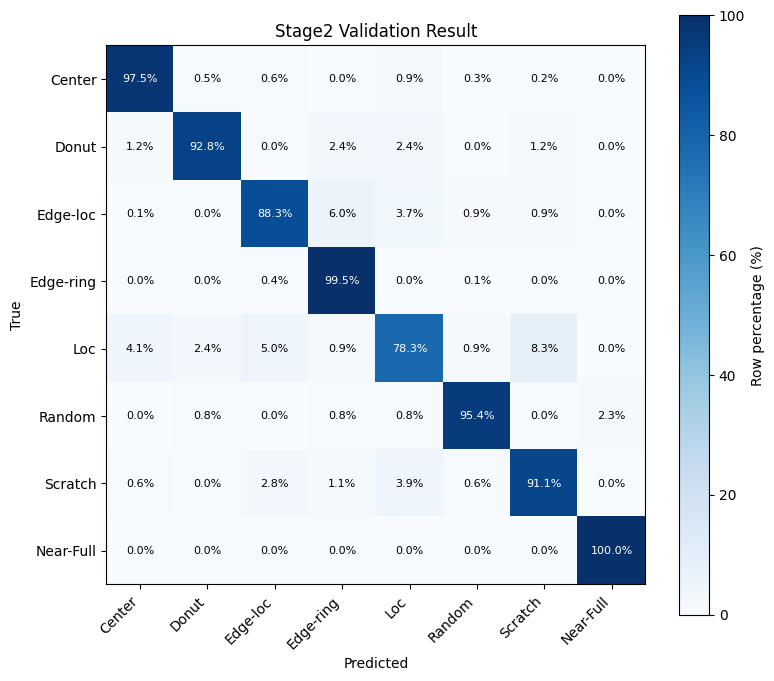

[INFO] Stage2 validation macro-F1 = 0.9060
[21:26:20] Cell 11 | Two-stage test prediction.


In [4]:



def evaluate_stage1_binary_report(true_folder, stage1_pred_name, title="Stage1 None vs Defect"):
    """Evaluate Stage1 as binary None/Defect classifier."""
    y_true_s1 = np.where(np.asarray(true_folder).astype(str) == NONE_CLASS_NAME, "None", "Defect")
    y_pred_s1 = np.asarray(stage1_pred_name).astype(str)
    labels_s1 = ["None", "Defect"]


    print("\n==============================")
    print(title)
    print("==============================")
    print(classification_report(
        y_true_s1,
        y_pred_s1,
        labels=labels_s1,
        target_names=labels_s1,
        digits=4,
        zero_division=0,
    ))


    cm = confusion_matrix(y_true_s1, y_pred_s1, labels=labels_s1)
    plot_cm(cm, labels_s1, title, normalize="true", show_counts=False)
    return cm




def evaluate_final_report(true_folder, final_pred, title="Final Two-stage Confusion Matrix"):
    """Evaluate final K+1 classification: None + 8 defect classes."""
    final_labels = [NONE_CLASS_NAME] + DEFECT_CLASS_LIST


    print("\n==============================")
    print("Final Two-stage Classification Report")
    print("==============================")
    print(classification_report(
        true_folder,
        final_pred,
        labels=final_labels,
        target_names=final_labels,
        digits=4,
        zero_division=0,
    ))


    final_macro_f1 = f1_score(
        true_folder,
        final_pred,
        labels=final_labels,
        average="macro",
        zero_division=0,
    )
    print(f"Final macro-F1 = {final_macro_f1:.4f}")


    cm = confusion_matrix(true_folder, final_pred, labels=final_labels)
    plot_cm(cm, final_labels, title, normalize="true", show_counts=False)
    return final_macro_f1, cm




def stage1_false_negative_analysis(df_out, none_class_name="None"):
    print("\n==============================")
    print("Stage1 False-Negative Analysis (Defect -> None)")
    print("==============================")
    df_fn = df_out[
        (df_out["true_folder"].astype(str) != "") &
        (df_out["true_folder"].astype(str) != none_class_name) &
        (df_out["stage1_pred"].astype(str) == "None")
    ].copy()
    if len(df_fn) == 0:
        print("No defect samples were rejected as None by Stage1.")
        return
    print(f"Total Stage1 false negatives: {len(df_fn)}")
    print(df_fn["true_folder"].value_counts().sort_index())
def build_samples(root_dir, classes):
    samples = []
    class_to_idx = {c: i for i, c in enumerate(classes)}
    for cls in classes:
        cls_dir = os.path.join(root_dir, cls)
        if not os.path.isdir(cls_dir):
            print(f"[WARN] Class folder not found: {cls_dir}")
            continue
















        for fn in sorted(os.listdir(cls_dir)):
            fp = os.path.join(cls_dir, fn)
            if not os.path.isfile(fp):
                continue



            rel = os.path.join(cls, fn)
            samples.append({
                "path": os.path.normpath(fp),
                "relpath": rel,
                "class_name": cls,
                "class_idx": class_to_idx[cls],
            })
    return samples, class_to_idx
def ensure_nonempty_samples(samples, name):
    if len(samples) == 0:
        raise RuntimeError(f"{name} has no samples. Please check dataset path and class folders.")
def random_subset_samples(dataset, max_samples, seed):
    """Randomly select up to max_samples items from a dataset.
    This is used during Greedy trial search.
    Each repeat can use a different training subset to reduce the chance
    that the selected augmentation is only good by coincidence.
    """
    if max_samples is None or max_samples <= 0:
        return dataset
    n = len(dataset)
    max_items = min(int(max_samples), n)
    rng = np.random.default_rng(seed)
    indices = rng.choice(n, size=max_items, replace=False)

    return Subset(dataset, indices.tolist())
# =========================================================
# 2) 你自寫的增強邏輯（CUSTOM PART）
# =========================================================
def wafer_dilation(img):
    img_np = np.array(img)
    kernel = np.ones((2, 2), np.uint8)
    img_np = cv2.dilate(img_np, kernel)
    return Image.fromarray(img_np)
def wafer_erosion(img):
    img_np = np.array(img)
    kernel = np.ones((2, 2), np.uint8)
    img_np = cv2.erode(img_np, kernel)
    return Image.fromarray(img_np)


def wafer_sharpen(img):
    img_np = np.array(img)
    kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
    img_np = cv2.filter2D(img_np, -1, kernel)
    return Image.fromarray(img_np)


def wafer_noise(img, rng):
    img_np = np.array(img)
    noise = rng.normal(5, 30, img_np.shape).astype(np.int16)
    img_np = np.clip(img_np.astype(np.int16) + noise, 0, 255).astype(np.uint8)
    return Image.fromarray(img_np)
def wafer_random_erasing(img, rng, erase_width_ratio=0.95, erase_height_ratio=0.05, safe_center_ratio=0.4):
    img_np = np.array(img)
    h, w, _ = img_np.shape
    erase_w = int(w * erase_width_ratio)
    erase_h = int(h * erase_height_ratio)
    erase_w = max(1, min(erase_w, w))
    erase_h = max(1, min(erase_h, h))
    center_x, center_y = w // 2, h // 2
    safe_radius_x = int(w * safe_center_ratio / 2)
    safe_radius_y = int(h * safe_center_ratio / 2)
    x0, y0 = 0, 0
    for _ in range(50):
        x0 = int(rng.integers(0, max(1, w - erase_w + 1)))
        y0 = int(rng.integers(0, max(1, h - erase_h + 1)))
        # 檢查 erase 區塊是否和中心安全區重疊。
        erase_x1 = x0 + erase_w
        erase_y1 = y0 + erase_h
        safe_x0 = center_x - safe_radius_x
        safe_x1 = center_x + safe_radius_x
        safe_y0 = center_y - safe_radius_y
        safe_y1 = center_y + safe_radius_y
        overlap_safe = not (
            erase_x1 <= safe_x0 or x0 >= safe_x1 or
            erase_y1 <= safe_y0 or y0 >= safe_y1
        )
        if not overlap_safe:
            break
    img_np[y0:y0 + erase_h, x0:x0 + erase_w, :] = 0
    return Image.fromarray(img_np)
def aug_apply_wafer(img_pil, op, rng):
    if op == "dilation":
        return wafer_dilation(img_pil)
    if op == "erosion":
        return wafer_erosion(img_pil)
    if op == "sharpen":
        return wafer_sharpen(img_pil)
    if op == "noise":
        return wafer_noise(img_pil, rng)
    if op == "erase":
        return wafer_random_erasing(img_pil, rng)
    return img_pil
# =========================================================
# 3) Dataset / DataLoader
# =========================================================
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
transform_imagenet = transforms.Compose([
    transforms.Resize(IMAGE_SIZE, interpolation=RESIZE_INTERPOLATION),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
class WaferDataset(Dataset):
    def __init__(
        self,
        samples,
        transform,
        binary_none_name=None,
        defect_only=False,


        pipeline=None,
        apply_prob=0.7,
        seed=42,
    ):
        self.transform = transform
        self.binary_none_name = binary_none_name
        self.defect_only = defect_only
        self.pipeline = list(pipeline) if pipeline else []
        self.apply_prob = float(apply_prob)
        self.seed = int(seed)
        if defect_only:
            self.samples = [s for s in samples if s["class_name"] != NONE_CLASS_NAME]
        else:
            self.samples = list(samples)
        pipe_sig = "|".join(self.pipeline).encode("utf-8")
        self.pipe_hash = zlib.crc32(pipe_sig) & 0xFFFFFFFF
        self.defect_name_to_idx = {name: i for i, name in enumerate(DEFECT_CLASS_LIST)}
    def __len__(self):
        return len(self.samples)
    def _apply_pipeline(self, img, idx):
        if not self.pipeline:
            return img
        s = (self.seed * 1000003 + idx * 1009 + self.pipe_hash) & 0xFFFFFFFF
        rng = np.random.default_rng(s)
        out = img
        for op in self.pipeline:
            if rng.random() < self.apply_prob:
                out = aug_apply_wafer(out, op, rng)
        return out
    def __getitem__(self, idx):
        row = self.samples[idx]
        img = Image.open(row["path"]).convert("RGB")
        img = self._apply_pipeline(img, idx)
        x = self.transform(img)
        if self.binary_none_name is not None:
            y = 0 if row["class_name"] == self.binary_none_name else 1
        elif self.defect_only:
            y = self.defect_name_to_idx[row["class_name"]]
        else:
            y = row["class_idx"]
        meta = {
            "path": row["path"],
            "relpath": row["relpath"],
            "class_name": row["class_name"],
        }
        return x, y, meta
def build_loader(dataset, batch_size, shuffle=False, sampler=None):
    loader_kwargs = {}
    if NUM_WORKERS > 0:
        loader_kwargs["persistent_workers"] = True
        loader_kwargs["prefetch_factor"] = 2




    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle if sampler is None else False,
        sampler=sampler,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        **loader_kwargs,
    )
# =========================================================
# 4) ImageNet 預訓練模型區（IMAGENET PRETRAINED PART）
# =========================================================
USE_IMAGENET_PRETRAINED_SWIN = True
PRETRAINED_MODEL_NAME = "swin_tiny_patch4_window7_224"

class SwinClassifierPT(nn.Module):
    def __init__(self, num_outputs, drop_rate=0.1):
        super().__init__()
        # v4 穩定版：完全使用 timm 內建的原始 ImageNet pretrained Swin Tiny。
        # 不傳 img_size，不傳 window_size，也不呼叫 set_input_size()。
        # 這樣可以避開：
        # 1) 64x64 token grid 16x16 無法被 window7 整除
        # 2) window_size 重複傳入
        # 3) 舊版 timm 沒有 set_input_size
        log(
            f"Creating timm model: {PRETRAINED_MODEL_NAME}, "
            f"pretrained={USE_IMAGENET_PRETRAINED_SWIN}, num_classes={num_outputs}"
        )
        self.backbone = timm.create_model(
            PRETRAINED_MODEL_NAME,
            pretrained=USE_IMAGENET_PRETRAINED_SWIN,
            num_classes=num_outputs,
            drop_rate=drop_rate,
        )
        log("timm model created successfully.")
















    def forward(self, x):
        return self.backbone(x)






def build_swin_classifier(
    num_outputs,
    final_activation=None,
    loss_name=None,
    input_shape=(224, 224, 3),
    patch_size=4,
    embed_dim=32,
    window_size=SWIN_WINDOW_SIZE,
    depths=(2, 2),
    num_heads=(2, 4),
    drop=0.1,
    lr=3e-5,
):
    # 這些參數保留只是為了和你原本的介面相容：
    # final_activation, loss_name, input_shape, patch_size, embed_dim,
    # window_size, depths, num_heads, lr。
    #
    # v4 穩定版真正使用的是 timm 原始 pretrained 模型：
    # swin_tiny_patch4_window7_224。
    #
    # 因此這裡不客製 img_size/window_size；輸入統一由 transform resize 成 224x224。
    model = SwinClassifierPT(
        num_outputs=num_outputs,
        drop_rate=drop,
    ).to(DEVICE)
    return model


def sanity_check_model_input():
    print("\n==============================")
    print("Sanity check: Swin input shape")
    print("==============================")
    tmp_model = build_swin_classifier(num_outputs=2, drop=SWIN_DROP)
    tmp_model.eval()
    with torch.no_grad():
        dummy = torch.randn(2, 3, IMAGE_SIZE[0], IMAGE_SIZE[1], device=DEVICE)
        out = tmp_model(dummy)
    print(f"Input shape  = {tuple(dummy.shape)}")
    print(f"Output shape = {tuple(out.shape)}")
    del tmp_model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()




# =========================================================
# 5) 訓練流程區
# =========================================================
@dataclass
class TrainOutput:
    best_state: dict
    best_val_loss: float




def safe_load_weights_if_compatible(model, weight_path):
    log(f"Checking weight file: {weight_path}")




    if not os.path.exists(weight_path):
        log(f"Weight file not found. Will train from pretrained initialization: {weight_path}")
        return False




    try:
        log("Loading saved model weights...")
        try:
            state = torch.load(weight_path, map_location=DEVICE, weights_only=True)
        except TypeError:
            state = torch.load(weight_path, map_location=DEVICE)
        model.load_state_dict(state)
        log(f"Loaded weights successfully: {weight_path}")
        return True




    except Exception as e:
        log(f"Weight load failed, will retrain: {weight_path}")
        log(f"Reason: {e}")
        return False












def save_weights(model, weight_path):
    os.makedirs(os.path.dirname(weight_path), exist_ok=True)
    torch.save(model.state_dict(), weight_path)
    log(f"Saved weights: {weight_path}")
































def run_one_epoch(model, loader, criterion, optimizer=None, phase="train", epoch=None, epochs=None):
    """Run one training/validation epoch with a visible tqdm progress bar."""
    is_train = optimizer is not None
    model.train(is_train)




    total_loss = 0.0
    total_correct = 0
    total_count = 0




    if epoch is not None and epochs is not None:
        desc = f"{phase} epoch {epoch}/{epochs}"
    else:
        desc = phase




    pbar = tqdm(loader, desc=desc, leave=False, mininterval=5)




    for batch_idx, (xb, yb, _) in enumerate(pbar, start=1):
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)




        if is_train:
            optimizer.zero_grad(set_to_none=True)




        with torch.set_grad_enabled(is_train):
            logits = model(xb)




            # Stage1: num_outputs=1 + BCEWithLogitsLoss
            if logits.ndim == 1 or logits.shape[-1] == 1:
                logits_flat = logits.view(-1)
                y_float = yb.float()
                loss = criterion(logits_flat, y_float)
                probs = torch.sigmoid(logits_flat)
                preds = (probs >= 0.5).long()




            # Stage2: num_outputs=8 + CrossEntropyLoss
            else:
                y_long = yb.long()
                loss = criterion(logits, y_long)
                preds = torch.argmax(logits, dim=1)




            if is_train:
                loss.backward()
                optimizer.step()




        total_loss += loss.item() * xb.size(0)
        total_correct += (preds == yb.long()).sum().item()
        total_count += xb.size(0)




        running_loss = total_loss / max(total_count, 1)
        running_acc = total_correct / max(total_count, 1)




        pbar.set_postfix({
            "loss": f"{running_loss:.4f}",
            "acc": f"{running_acc:.4f}",
            "seen": total_count,
        })




    avg_loss = total_loss / max(total_count, 1)
    avg_acc = total_correct / max(total_count, 1)
    return avg_loss, avg_acc
































def train_model_pt(
    model,
    train_loader,
    val_loader,
    criterion,
    lr,
    epochs,
    patience,
):
    optimizer = Adam(model.parameters(), lr=lr)
    scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2, min_lr=1e-6)
















    best_state = copy.deepcopy(model.state_dict())
    best_val_loss = np.inf
    wait = 0
















    for ep in range(1, epochs + 1):
        log(f"Start epoch {ep}/{epochs} training...")
        tr_loss, tr_acc = run_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer=optimizer,
            phase="train",
            epoch=ep,
            epochs=epochs,
        )




        log(f"Start epoch {ep}/{epochs} validation...")
        va_loss, va_acc = run_one_epoch(
            model,
            val_loader,
            criterion,
            optimizer=None,
            phase="val",
            epoch=ep,
            epochs=epochs,
        )




        scheduler.step(va_loss)




        log(
            f"Epoch {ep:02d}/{epochs} | "
            f"train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} | "
            f"val_loss={va_loss:.4f} val_acc={va_acc:.4f}"
        )
















        if va_loss < best_val_loss:
            best_val_loss = va_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                log("Early stopping triggered")
                break
















    model.load_state_dict(best_state)
    return TrainOutput(best_state=best_state, best_val_loss=float(best_val_loss))
































def predict_prob_stage1(model, loader):
    model.eval()
    probs = []
    with torch.no_grad():
        for xb, _, _ in tqdm(loader, desc="predict Stage1", leave=False, mininterval=5):
            xb = xb.to(DEVICE, non_blocking=True)
            logits = model(xb).view(-1)
            p = torch.sigmoid(logits)
            probs.append(p.detach().cpu().numpy())
    return np.concatenate(probs, axis=0)
































def predict_stage2(model, loader):
    model.eval()
    probs = []
    metas = []
    with torch.no_grad():
        for xb, _, mb in tqdm(loader, desc="predict Stage2", leave=False, mininterval=5):
            xb = xb.to(DEVICE, non_blocking=True)
            logits = model(xb)
            p = torch.softmax(logits, dim=1)
            probs.append(p.detach().cpu().numpy())
            metas.extend([{k: mb[k][i] for k in mb} for i in range(len(mb["path"]))])
    return np.concatenate(probs, axis=0), metas
































def collect_labels(loader):
    ys = []
    metas = []
    for _, yb, mb in tqdm(loader, desc="collect labels", leave=False, mininterval=5):
        ys.extend(yb.numpy().tolist())
        metas.extend([{k: mb[k][i] for k in mb} for i in range(len(mb["path"]))])
    return np.array(ys, dtype=np.int64), metas












def tune_stage1_threshold(model, val_loader, threshold_grid=None):
    if threshold_grid is None:
        threshold_grid = np.arange(0.10, 0.91, 0.05)
    val_prob = predict_prob_stage1(model, val_loader)
    y_val_true, _ = collect_labels(val_loader)
    print("\n==============================")
    print("Tune Stage1 Threshold on Validation Set")
    print("==============================")
    best_th = 0.50
    best_recall = -1.0
    best_f1 = -1.0
    for th in threshold_grid:
        y_pred = (val_prob >= th).astype(int)
        tp = np.sum((y_val_true == 1) & (y_pred == 1))
        fn = np.sum((y_val_true == 1) & (y_pred == 0))
        fp = np.sum((y_val_true == 0) & (y_pred == 1))
        recall_defect = tp / (tp + fn + 1e-8)
        precision_defect = tp / (tp + fp + 1e-8)
        f1_defect = 2 * precision_defect * recall_defect / (precision_defect + recall_defect + 1e-8)
















        print(f"th={th:.2f} | recall={recall_defect:.4f} | precision={precision_defect:.4f} | f1={f1_defect:.4f}")
















        if (recall_defect > best_recall) or (np.isclose(recall_defect, best_recall) and f1_defect > best_f1):
            best_recall = recall_defect
            best_f1 = f1_defect
            best_th = float(th)








    print(f"\n[Selected Stage1 threshold] {best_th:.2f}")
    return best_th
def evaluate_stage2(model, loader, title):
    probs, metas = predict_stage2(model, loader)
    y_pred = np.argmax(probs, axis=1)
    y_true, _ = collect_labels(loader)


    print("\n==============================")
    print(title)
    print("==============================")
    print(classification_report(
        y_true,
        y_pred,
        labels=list(range(len(DEFECT_CLASS_LIST))),
        target_names=DEFECT_CLASS_LIST,
        digits=4,
        zero_division=0,
    ))
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    print(f"{title} macro-F1 = {macro_f1:.4f}")
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(DEFECT_CLASS_LIST))))
    plot_cm(cm, DEFECT_CLASS_LIST, title, normalize="true", show_counts=False)
    return macro_f1


def evaluate_stage2_macro_f1_only(model, loader):
    """Fast Stage2 evaluation used inside Greedy search.
    This function only computes validation macro-F1.
    It does not print classification_report and does not plot confusion matrix,
    so Greedy search is much faster and cleaner.
    """
    model.eval()








    all_pred = []
    all_true = []








    with torch.no_grad():
        for xb, yb, _ in loader:
            xb = xb.to(DEVICE, non_blocking=True)
            logits = model(xb)
            pred = torch.argmax(logits, dim=1).detach().cpu().numpy()








            all_pred.extend(pred.tolist())
            all_true.extend(yb.numpy().tolist())








    return f1_score(
        np.asarray(all_true, dtype=np.int64),
        np.asarray(all_pred, dtype=np.int64),
        labels=list(range(len(DEFECT_CLASS_LIST))),
        average="macro",
        zero_division=0,
    )
# =========================================================
# 6) Greedy augmentation search for Stage2
# =========================================================
def set_all_seeds(seed):
    """Set random seeds for one Greedy repeat."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
def evaluate_stage2_pipeline_once(train_samples, val_samples, pipeline, trial_epochs, repeat_seed):
    """Run one trial training for one candidate pipeline and return one macro-F1 score.
    repeat_seed controls:
    1. model initialization randomness
    2. dataloader shuffle randomness
    3. augmentation randomness
    4. random training subset sampling
    """
    set_all_seeds(repeat_seed)
    trial_train_ds = WaferDataset(
        train_samples,
        transform_imagenet,
        defect_only=True,
        pipeline=pipeline,
        apply_prob=0.7,
        seed=repeat_seed,
    )
    trial_val_ds = WaferDataset(
        val_samples,
        transform_imagenet,
        defect_only=True,
        pipeline=None,
        seed=SEED,
    )
    # Training subset: randomly sampled for each repeat.
    trial_train_ds = random_subset_samples(
        trial_train_ds,
        GREEDY_TRAIN_SAMPLES,
        seed=repeat_seed,
    )
    # Validation set: fixed for fairness across candidates.
    # If GREEDY_VAL_SAMPLES is None, this returns the full validation set.
    trial_val_ds = random_subset_samples(
        trial_val_ds,
        GREEDY_VAL_SAMPLES,
        seed=SEED,
    )


    trial_train_loader = build_loader(trial_train_ds, BATCH_SIZE, shuffle=True)
    trial_val_loader = build_loader(trial_val_ds, BATCH_SIZE, shuffle=False)
    trial_model = build_swin_classifier(
        num_outputs=len(DEFECT_CLASS_LIST),
        final_activation=None,
        loss_name="ce",
        drop=SWIN_DROP,
    )








    criterion = nn.CrossEntropyLoss(weight=weight_tensor_s2)








    train_model_pt(
        trial_model,
        trial_train_loader,
        trial_val_loader,
        criterion,
        lr=SWIN_LR,
        epochs=trial_epochs,
        patience=max(1, trial_epochs),
    )








    if GREEDY_FAST_EVAL:
        score = evaluate_stage2_macro_f1_only(trial_model, trial_val_loader)
        print(
            f"[Greedy trial] pipeline={pipeline}, seed={repeat_seed}, "
            f"macro-F1={score:.4f}"
        )
    else:
        score = evaluate_stage2(
            trial_model,
            trial_val_loader,
            title=f"Greedy trial pipeline={pipeline}, seed={repeat_seed}",
        )








    del trial_model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()








    return float(score)
















def evaluate_stage2_pipeline_repeated(train_samples, val_samples, pipeline, trial_epochs):
    """Evaluate one candidate pipeline multiple times.
    Returns:
        mean_score: average validation macro-F1
        std_score : standard deviation of validation macro-F1
        scores    : all repeat scores
    """
    scores = []
    for repeat_id in range(GREEDY_REPEATS):
        # Same repeat_id uses the same base seed across different candidates.
        # This makes candidate comparison more controlled.
        repeat_seed = SEED + 1000 * repeat_id








        score = evaluate_stage2_pipeline_once(
            train_samples,
            val_samples,
            pipeline,
            trial_epochs,
            repeat_seed=repeat_seed,
        )
        scores.append(score)








    scores = np.asarray(scores, dtype=np.float64)
    mean_score = float(scores.mean())
    std_score = float(scores.std(ddof=1)) if len(scores) > 1 else 0.0








    print(
        f"[Greedy repeated] pipeline={pipeline}, "
        f"scores={np.round(scores, 4).tolist()}, "
        f"mean={mean_score:.4f}, std={std_score:.4f}"
    )








    return mean_score, std_score, scores.tolist()
















def greedy_search_stage2(train_samples, val_samples):
    print("\n==============================")
    print("Greedy Search for Stage2 Augmentation Pipeline")
    print("Repeated evaluation: mean ± std macro-F1")
    print("==============================")








    selected = []








    # Baseline: no augmentation.
    best_score, best_std, best_scores = evaluate_stage2_pipeline_repeated(
        train_samples,
        val_samples,
        selected,
        TRIAL_EPOCHS,
    )








    print(
        f"[Greedy baseline] pipeline={selected}, "
        f"mean_macro-F1={best_score:.4f}, std={best_std:.4f}"
    )








    greedy_records = [{
        "round": 0,
        "candidate_op": "baseline",
        "pipeline": "",
        "mean_macro_f1": best_score,
        "std_macro_f1": best_std,
        "scores": "|".join(f"{s:.4f}" for s in best_scores),
        "selected": True,
    }]


    for round_id in range(1, MAX_ROUNDS + 1):
        print(f"\n[Greedy Round {round_id}/{MAX_ROUNDS}]")








        round_best_op = None
        round_best_score = best_score
        round_best_std = best_std
        round_best_scores = None








        for op in CANDIDATES:
            if op in selected:
                continue








            candidate_pipeline = selected + [op]








            mean_score, std_score, scores = evaluate_stage2_pipeline_repeated(
                train_samples,
                val_samples,
                candidate_pipeline,
                TRIAL_EPOCHS,
            )








            # Primary rule: choose higher mean macro-F1.
            # Tie-breaking rule: if mean is almost the same, choose lower std for stability.
            improved = (
                mean_score > round_best_score or
                (np.isclose(mean_score, round_best_score) and std_score < round_best_std)
            )








            greedy_records.append({
                "round": round_id,
                "candidate_op": op,
                "pipeline": "|".join(candidate_pipeline),
                "mean_macro_f1": mean_score,
                "std_macro_f1": std_score,
                "scores": "|".join(f"{s:.4f}" for s in scores),
                "selected": False,
            })








            print(
                f"[Greedy] try={candidate_pipeline}, "
                f"mean_macro-F1={mean_score:.4f}, std={std_score:.4f}, "
                f"improved={improved}"
            )








            if improved:
                round_best_score = mean_score
                round_best_std = std_score
                round_best_scores = scores
                round_best_op = op








        mean_gain = round_best_score - best_score
        print(f"[Greedy] best_op={round_best_op}, mean_gain={mean_gain:.4f}")








        if round_best_op is None:
            print("[Greedy] stop: no candidate improved mean macro-F1")
            break








        selected.append(round_best_op)
        best_score = round_best_score
        best_std = round_best_std
        best_scores = round_best_scores








        # Mark the selected candidate in this round.
        for rec in reversed(greedy_records):
            if rec["round"] == round_id and rec["candidate_op"] == round_best_op:
                rec["selected"] = True
                break








        print(
            f"[Greedy] selected={selected}, "
            f"best_mean_macro-F1={best_score:.4f}, std={best_std:.4f}"
        )








    df_greedy = pd.DataFrame(greedy_records)
    os.makedirs(os.path.dirname(OUT_GREEDY_CSV), exist_ok=True)
    df_greedy.to_csv(OUT_GREEDY_CSV, index=False, encoding="utf-8-sig")
    print(f"[INFO] Saved greedy result: {OUT_GREEDY_CSV}")








    return selected


# =========================================================
# 7) Notebook cells: run step by step, NOT one big main()
# =========================================================
# 使用方式：
# 1. 先執行上面所有 function / class 定義。
# 2. 從下面 Cell 01 開始一格一格執行。
# 3. 如果某一格出錯，只修正該格或相關 function，然後從該格繼續，不需要重跑全部。
# 4. 不要再使用 if __name__ == "__main__": main()。


# %% [Cell 01] 初始化、建立資料夾、檢查 Swin 輸入
log("Cell 01 | Program started.")
os.makedirs(DATASET_DIR1, exist_ok=True)
sanity_check_model_input()


# %% [Cell 02] 掃描 train / val / test 資料
log("Cell 02 | Build samples from dataset folders.")
train_samples, _ = build_samples(TRAIN_DIR, CLASS_LIST)
val_samples, _ = build_samples(VAL_DIR, CLASS_LIST)
test_samples, _ = build_samples(TEST_DIR, CLASS_LIST)


ensure_nonempty_samples(train_samples, "train_samples")
ensure_nonempty_samples(val_samples, "val_samples")
ensure_nonempty_samples(test_samples, "test_samples")


print("\n==============================")
print("Dataset Summary")
print("==============================")
print(f"train samples = {len(train_samples)}")
print(f"val samples   = {len(val_samples)}")
print(f"test samples  = {len(test_samples)}")


# %% [Cell 03] 建立 Dataset / DataLoader
log("Cell 03 | Build datasets and dataloaders.")
train_ds_stage1 = WaferDataset(train_samples, transform_imagenet, binary_none_name=NONE_CLASS_NAME)
val_ds_stage1 = WaferDataset(val_samples, transform_imagenet, binary_none_name=NONE_CLASS_NAME)
test_ds_stage1 = WaferDataset(test_samples, transform_imagenet, binary_none_name=NONE_CLASS_NAME)


train_ds_stage2_plain = WaferDataset(train_samples, transform_imagenet, defect_only=True)
val_ds_stage2 = WaferDataset(val_samples, transform_imagenet, defect_only=True)
test_ds_all = WaferDataset(test_samples, transform_imagenet, defect_only=False)


train_bin = build_loader(train_ds_stage1, BATCH_SIZE, shuffle=True)
val_bin = build_loader(val_ds_stage1, BATCH_SIZE, shuffle=False)
test_bin = build_loader(test_ds_stage1, 1, shuffle=False)


train_def_flow_plain = build_loader(train_ds_stage2_plain, BATCH_SIZE, shuffle=True)
val_def_flow = build_loader(val_ds_stage2, BATCH_SIZE, shuffle=False)
test_all_flow = build_loader(test_ds_all, 1, shuffle=False)


print("Stage2 num_classes =", len(DEFECT_CLASS_LIST))
print("Stage2 class_indices =", {k: i for i, k in enumerate(DEFECT_CLASS_LIST)})


# %% [Cell 04] 快速計算 Stage1 / Stage2 class weights
log("Cell 04 | Compute class weights from train_samples without loading images.")


print("\n==============================")
print("Compute class_weight for Stage1 (None vs Defect) [FAST]")
print("==============================")


train_class_names = np.array([s["class_name"] for s in train_samples], dtype=object)


n_none = int(np.sum(train_class_names == NONE_CLASS_NAME))
n_def = int(np.sum(train_class_names != NONE_CLASS_NAME))


print(f"Stage1 None count   = {n_none}")
print(f"Stage1 Defect count = {n_def}")


stage1_pos_weight = torch.tensor([n_none / max(n_def, 1)], dtype=torch.float32, device=DEVICE)
print("Stage1 pos_weight =", float(stage1_pos_weight.item()))


print("\n==============================")
print("Compute class_weight for Stage2 (defect-only, sum=100) [FAST]")
print("==============================")


defect_name_to_idx = {name: i for i, name in enumerate(DEFECT_CLASS_LIST)}
y_stage2_fast = np.array([defect_name_to_idx[name] for name in train_class_names if name != NONE_CLASS_NAME], dtype=np.int64)


counts = np.bincount(y_stage2_fast, minlength=len(DEFECT_CLASS_LIST)).astype(np.float64)
counts_safe = np.where(counts == 0, 1.0, counts)


n_samples = float(len(y_stage2_fast))
raw_w = n_samples / (len(DEFECT_CLASS_LIST) * counts_safe)


TOTAL_WEIGHT = 100.0
raw_map = {i: float(raw_w[i]) for i in range(len(DEFECT_CLASS_LIST)) if counts[i] > 0}
sum_w = sum(raw_map.values())
class_weights_s2 = {k: (v / sum_w) * TOTAL_WEIGHT for k, v in raw_map.items()}


print("-" * 70)
for idx in sorted(class_weights_s2.keys()):
    name = DEFECT_CLASS_LIST[idx]
    print(f"{name:<12} (class {idx}): count={int(counts[idx]):5d}  weight={class_weights_s2[idx]:8.3f}")
print("-" * 70)
print(f"SUM = {sum(class_weights_s2.values()):.2f}")


weight_tensor_s2 = torch.ones(len(DEFECT_CLASS_LIST), dtype=torch.float32, device=DEVICE)
for k, v in class_weights_s2.items():
    weight_tensor_s2[k] = float(v)


print("[INFO] Pure PyTorch pipeline ready")
print(f"[INFO] Stage1 weight path: {STAGE1_weight_pth}")
print(f"[INFO] Stage2 weight path: {STAGE2_weight_pth}")
print(f"[INFO] Swin window size = {SWIN_WINDOW_SIZE}")


# %% [Cell 05] Stage1：建立 / 載入 / 訓練
log("Cell 05 | Stage1: None vs Defect.")


print("\n==============================")
print("Stage1: None vs Defect")
print("==============================")


log("Building Stage1 Swin model...")
stage1 = build_swin_classifier(num_outputs=1, final_activation=None, loss_name="bce", drop=SWIN_DROP)
log("Stage1 Swin model built.")


criterion_stage1 = nn.BCEWithLogitsLoss(pos_weight=stage1_pos_weight)


loaded_stage1 = False
if not FORCE_RETRAIN_STAGE1:
    loaded_stage1 = safe_load_weights_if_compatible(stage1, STAGE1_weight_pth)


if not loaded_stage1:
    log("Stage1 weights not loaded. Start Stage1 training.")
    train_model_pt(stage1, train_bin, val_bin, criterion_stage1, lr=SWIN_LR, epochs=EPOCHS_STAGE1, patience=4)
    save_weights(stage1, STAGE1_weight_pth)
else:
    log("Stage1 training skipped because saved weights were loaded.")


# %% [Cell 06] Stage1 threshold tuning
log("Cell 06 | Tune Stage1 threshold on validation set.")
THRESH_STAGE1 = tune_stage1_threshold(stage1, val_bin)
print(f"[INFO] THRESH_STAGE1 = {THRESH_STAGE1:.2f}")


# %% [Cell 07] Greedy augmentation search，可跳過
log("Cell 07 | Greedy augmentation search for Stage2.")


# 若只想先跑完整主流程，可手動改：
RUN_GREEDY = False
USE_GREEDY_FOR_STAGE2 = True

greedy_selected =  ['erosion']

stage2_pipeline = greedy_selected

# 注意：這裡一定要是小寫 stage2_pipeline
stage2_pipeline = greedy_selected if USE_GREEDY_FOR_STAGE2 else []

print(f"[INFO] RUN_GREEDY = {RUN_GREEDY}")
print(f"[INFO] USE_GREEDY_FOR_STAGE2 = {USE_GREEDY_FOR_STAGE2}")
print(f"[INFO] Stage2 training pipeline = {stage2_pipeline}")


#if RUN_GREEDY:
#    log("Start Greedy augmentation search for Stage2.")
#    greedy_selected = greedy_search_stage2(train_samples, val_samples)
#else:
#    log("Greedy augmentation search skipped because RUN_GREEDY=False.")


#stage2_pipeline = greedy_selected if USE_GREEDY_FOR_STAGE2 else []
#print(f"[INFO] Stage2 training pipeline = {stage2_pipeline}")



# %% [Cell 08] 根據 Greedy 結果建立 Stage2 training loader
log("Cell 08 | Build Stage2 train loader with selected augmentation pipeline.")


train_ds_stage2 = WaferDataset(train_samples, transform_imagenet, defect_only=True, pipeline=stage2_pipeline, apply_prob=0.7, seed=SEED)
train_def_flow = build_loader(train_ds_stage2, BATCH_SIZE, shuffle=True)


print(f"[INFO] Stage2 train dataset size = {len(train_ds_stage2)}")
print(f"[INFO] Stage2 pipeline = {stage2_pipeline}")


# %% [Cell 09] Stage2：建立 / 載入 / 訓練
log("Cell 09 | Stage2: Defect-only 8-class classification.")


print("\n==============================")
print("Stage2: Defect-only 8-class Classification")
print("==============================")


log("Building Stage2 Swin model...")
stage2 = build_swin_classifier(num_outputs=len(DEFECT_CLASS_LIST), final_activation=None, loss_name="ce", drop=SWIN_DROP)
log("Stage2 Swin model built.")


criterion_stage2 = nn.CrossEntropyLoss(weight=weight_tensor_s2)


loaded_stage2 = False
if not FORCE_RETRAIN_STAGE2:
    loaded_stage2 = safe_load_weights_if_compatible(stage2, STAGE2_weight_pth)


if not loaded_stage2:
    log("Stage2 weights not loaded. Start Stage2 training.")
    train_model_pt(stage2, train_def_flow, val_def_flow, criterion_stage2, lr=SWIN_LR, epochs=EPOCHS_STAGE2, patience=5)
    save_weights(stage2, STAGE2_weight_pth)
else:
    log("Stage2 training skipped because saved weights were loaded.")


# %% [Cell 10] Stage2 validation evaluation
log("Cell 10 | Stage2 validation evaluation.")
stage2_val_macro_f1 = evaluate_stage2(stage2, val_def_flow, title="Stage2 Validation Result")
print(f"[INFO] Stage2 validation macro-F1 = {stage2_val_macro_f1:.4f}")


# %% [Cell 11] Two-stage test prediction，輸出 CSV
log("Cell 11 | Two-stage test prediction.")



Two-stage Test
[21:26:20] Start Stage1 test prediction...


[21:35:45] Start Stage2 test prediction for all test samples...


[INFO] Saved test predictions: C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Python\swinlr3\test_greedy_two_stage_predictions_src64_to224_swin.csv
[21:45:03] Cell 12 | Stage1 binary test report and confusion matrix.

TEST Stage1 None vs Defect
              precision    recall  f1-score   support

        None     0.9983    0.9370    0.9667     22115
      Defect     0.7313    0.9909    0.8415      3828

    accuracy                         0.9449     25943
   macro avg     0.8648    0.9639    0.9041     25943
weighted avg     0.9589    0.9449    0.9482     25943



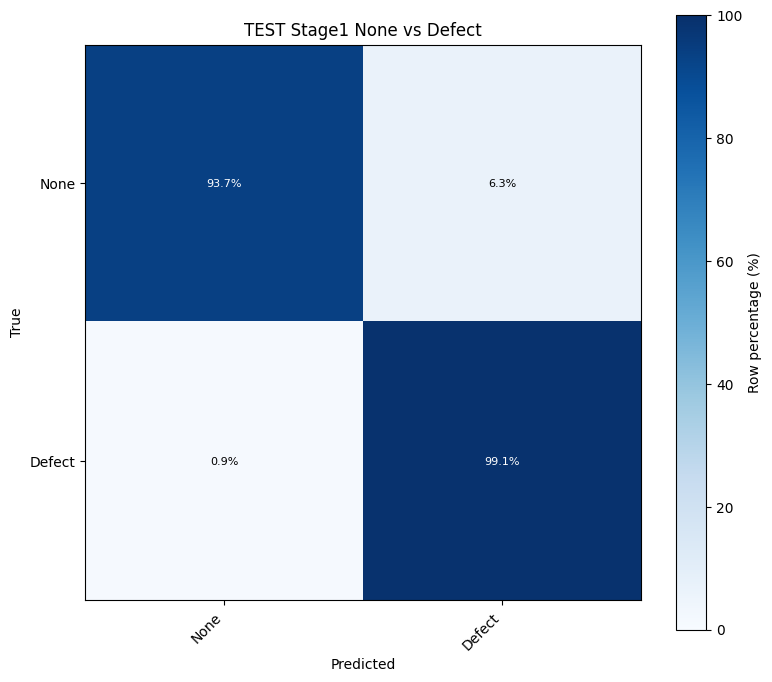

[21:45:03] Cell 13 | Final two-stage report and confusion matrix.

Final Two-stage Classification Report
              precision    recall  f1-score   support

        None     0.9983    0.9370    0.9667     22115
      Center     0.5922    0.9627    0.7333       644
       Donut     0.7677    0.9157    0.8352        83
    Edge-loc     0.6304    0.8626    0.7285       779
   Edge-ring     0.9112    0.9897    0.9488      1452
         Loc     0.5111    0.7662    0.6132       539
      Random     0.6582    0.9923    0.7914       130
     Scratch     0.4394    0.9106    0.5927       179
   Near-Full     0.9565    1.0000    0.9778        22

    accuracy                         0.9349     25943
   macro avg     0.7183    0.9263    0.7986     25943
weighted avg     0.9559    0.9349    0.9415     25943

Final macro-F1 = 0.7986


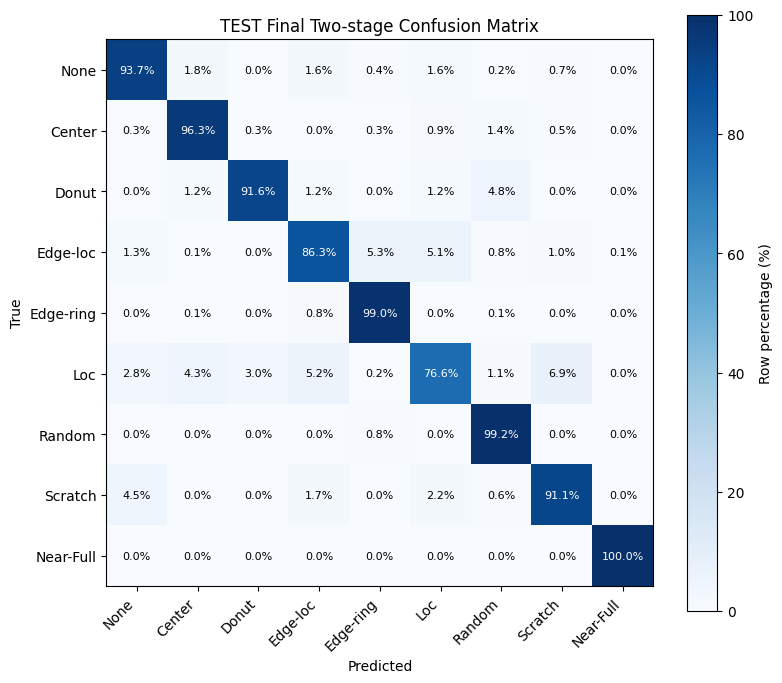

[21:45:04] Cell 14 | Stage1 false negative analysis.

Stage1 False-Negative Analysis (Defect -> None)
Total Stage1 false negatives: 35
true_folder
Center       2
Edge-loc    10
Loc         15
Scratch      8
Name: count, dtype: int64

[INFO] Done.


In [5]:


print("\n==============================")
print("Two-stage Test")
print("==============================")


log("Start Stage1 test prediction...")
stage1_test_prob = predict_prob_stage1(stage1, test_bin)
stage1_pred_bin = (stage1_test_prob >= THRESH_STAGE1).astype(int)
stage1_pred_name = np.where(stage1_pred_bin == 1, "Defect", "None")


log("Start Stage2 test prediction for all test samples...")
stage2_test_prob, metas = predict_stage2(stage2, test_all_flow)
stage2_pred_idx = np.argmax(stage2_test_prob, axis=1)
stage2_pred_name = np.array([DEFECT_CLASS_LIST[i] for i in stage2_pred_idx])


final_pred = np.where(stage1_pred_bin == 0, NONE_CLASS_NAME, stage2_pred_name)
true_folder = np.array([m["class_name"] for m in metas])


df_out = pd.DataFrame({
    "path": [m["path"] for m in metas],
    "relpath": [m["relpath"] for m in metas],
    "true_folder": true_folder,
    "stage1_prob_defect": stage1_test_prob,
    "stage1_pred": stage1_pred_name,
    "stage2_pred": stage2_pred_name,
    "final_pred": final_pred,
})


os.makedirs(os.path.dirname(OUT_TEST_CSV), exist_ok=True)
df_out.to_csv(OUT_TEST_CSV, index=False, encoding="utf-8-sig")
print(f"[INFO] Saved test predictions: {OUT_TEST_CSV}")


# %% [Cell 12] Stage1 binary report + confusion matrix
log("Cell 12 | Stage1 binary test report and confusion matrix.")
stage1_cm = evaluate_stage1_binary_report(true_folder, stage1_pred_name, title="TEST Stage1 None vs Defect")


# %% [Cell 13] Final two-stage report + confusion matrix
log("Cell 13 | Final two-stage report and confusion matrix.")
final_macro_f1, final_cm = evaluate_final_report(true_folder, final_pred, title="TEST Final Two-stage Confusion Matrix")


# %% [Cell 14] Stage1 false negative analysis
log("Cell 14 | Stage1 false negative analysis.")
stage1_false_negative_analysis(df_out, none_class_name=NONE_CLASS_NAME)
print("\n[INFO] Done.")



TEST Stage2 Confusion Matrix: Defect-only 8 Classes


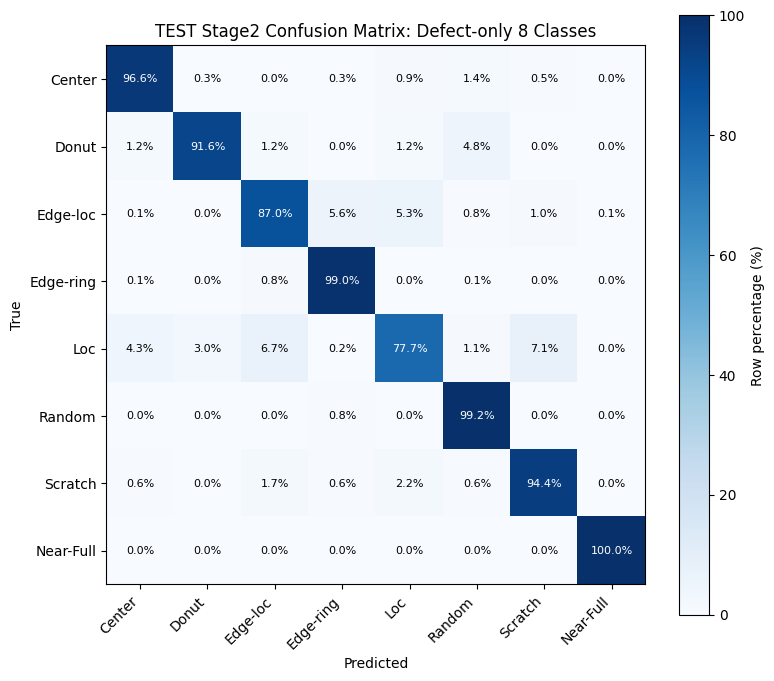

In [6]:
def plot_cm_percent_only(cm, labels, title, figsize=(8, 7)):
    """
    只顯示百分比的 confusion matrix。
    不顯示 count，所以每格只會有一行，例如：97.5%
    """
    import matplotlib.pyplot as plt
    import numpy as np

    cm = np.asarray(cm, dtype=np.float64)

    row_sum = cm.sum(axis=1, keepdims=True)

    cm_pct = np.divide(
        cm,
        row_sum,
        out=np.zeros_like(cm),
        where=row_sum != 0
    ) * 100.0

    plt.figure(figsize=figsize)
    plt.imshow(cm_pct, interpolation="nearest", cmap="Blues", vmin=0, vmax=100)
    plt.title(title)

    cbar = plt.colorbar()
    cbar.set_label("Row percentage (%)")

    plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
    plt.yticks(range(len(labels)), labels)

    plt.xlabel("Predicted")
    plt.ylabel("True")

    for i in range(cm_pct.shape[0]):
        for j in range(cm_pct.shape[1]):
            pct = cm_pct[i, j]
            color = "white" if pct > 50 else "black"

            plt.text(
                j,
                i,
                f"{pct:.1f}%",
                ha="center",
                va="center",
                color=color,
                fontsize=8,
            )

    plt.tight_layout()
    plt.show()
# =====================================================
# Re-plot TEST Stage2 Confusion Matrix
# Defect-only 8 Classes
# 只顯示百分比，不顯示 count
# =====================================================

print("\n==============================")
print("TEST Stage2 Confusion Matrix: Defect-only 8 Classes")
print("==============================")

# 如果目前 notebook 裡沒有 df_out，就從 CSV 讀回來
if "df_out" not in globals():
    df_out = pd.read_csv(OUT_TEST_CSV, encoding="utf-8-sig")
    print(f"[INFO] Loaded df_out from: {OUT_TEST_CSV}")

# 只取真實類別是 defect 的 test samples
df_test_defect = df_out[
    df_out["true_folder"].astype(str) != NONE_CLASS_NAME
].copy()

y_true_stage2 = df_test_defect["true_folder"].astype(str).values
y_pred_stage2 = df_test_defect["stage2_pred"].astype(str).values

stage2_labels = DEFECT_CLASS_LIST

cm_stage2 = confusion_matrix(
    y_true_stage2,
    y_pred_stage2,
    labels=stage2_labels
)

plot_cm_percent_only(
    cm_stage2,
    stage2_labels,
    "TEST Stage2 Confusion Matrix: Defect-only 8 Classes",
    figsize=(8, 7)
)



TEST Stage1 Confusion Matrix: None vs Defect
              precision    recall  f1-score   support

        None     0.9983    0.9370    0.9667     22115
      Defect     0.7313    0.9909    0.8415      3828

    accuracy                         0.9449     25943
   macro avg     0.8648    0.9639    0.9041     25943
weighted avg     0.9589    0.9449    0.9482     25943



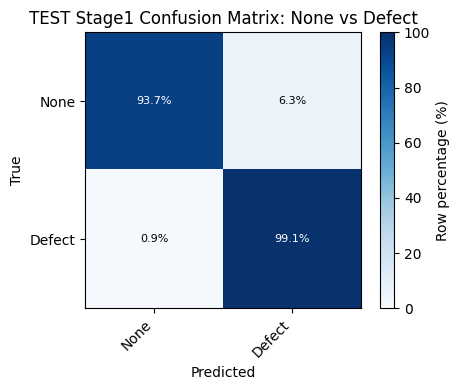


TEST Stage2 Confusion Matrix: Defect-only 8 Classes
              precision    recall  f1-score   support

      Center     0.9584    0.9658    0.9621       644
       Donut     0.8085    0.9157    0.8588        83
    Edge-loc     0.9288    0.8703    0.8986       779
   Edge-ring     0.9670    0.9897    0.9782      1452
         Loc     0.8896    0.7774    0.8297       539
      Random     0.8217    0.9923    0.8990       130
     Scratch     0.7752    0.9441    0.8514       179
   Near-Full     0.9565    1.0000    0.9778        22

    accuracy                         0.9279      3828
   macro avg     0.8882    0.9319    0.9069      3828
weighted avg     0.9295    0.9279    0.9272      3828



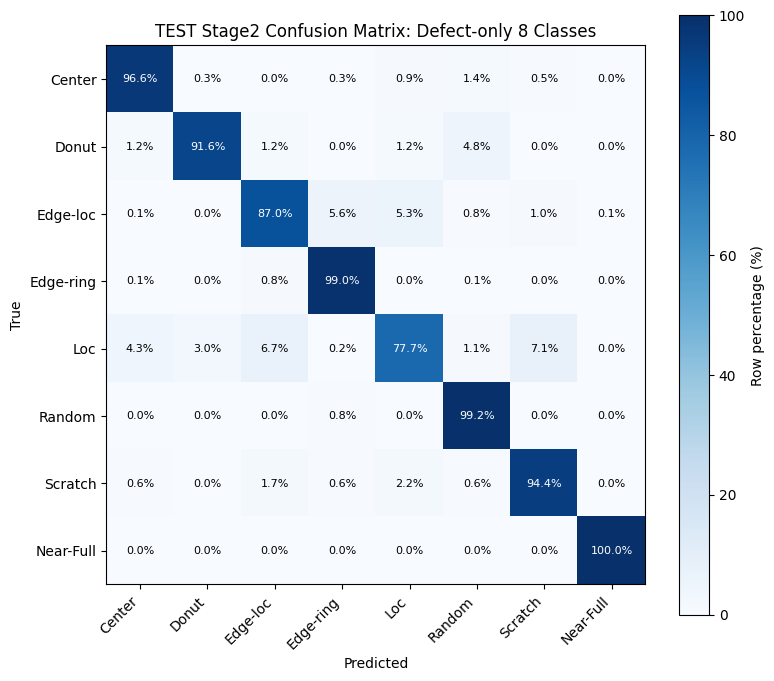


TEST Final Two-stage Confusion Matrix: None + 8 Classes
              precision    recall  f1-score   support

        None     0.9983    0.9370    0.9667     22115
      Center     0.5922    0.9627    0.7333       644
       Donut     0.7677    0.9157    0.8352        83
    Edge-loc     0.6304    0.8626    0.7285       779
   Edge-ring     0.9112    0.9897    0.9488      1452
         Loc     0.5111    0.7662    0.6132       539
      Random     0.6582    0.9923    0.7914       130
     Scratch     0.4394    0.9106    0.5927       179
   Near-Full     0.9565    1.0000    0.9778        22

    accuracy                         0.9349     25943
   macro avg     0.7183    0.9263    0.7986     25943
weighted avg     0.9559    0.9349    0.9415     25943

TEST Final macro-F1 = 0.7986


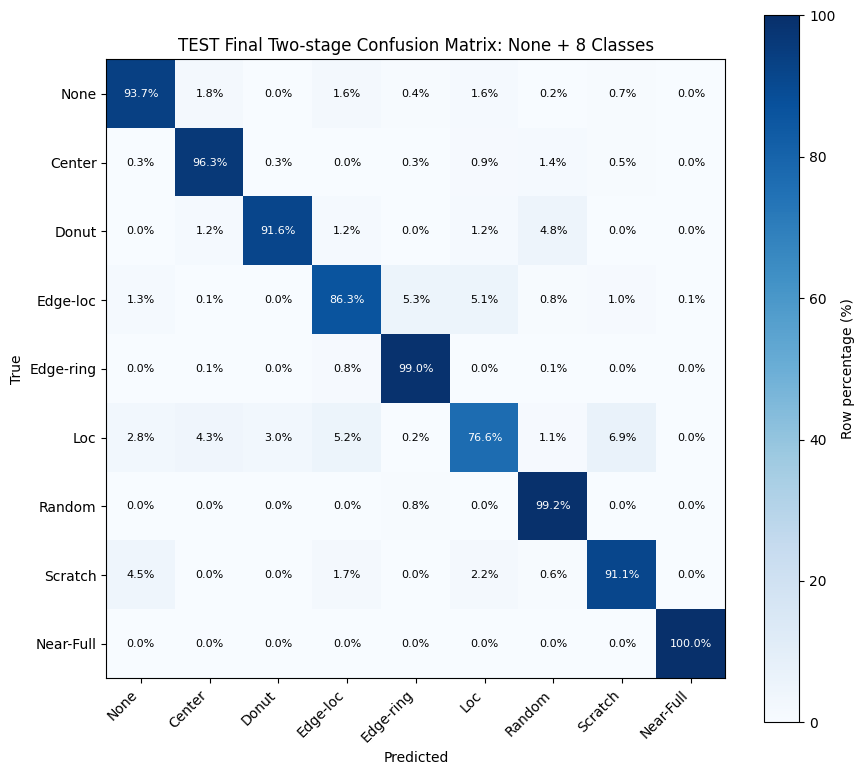

In [7]:
# =====================================================
# Re-plot TEST Confusion Matrices
# Stage1 / Stage2 / Final
# 只顯示百分比，不顯示 count
# 不重新訓練、不重新推論
# =====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, f1_score


def plot_cm_percent_only(cm, labels, title, figsize=(8, 7)):
    """
    只顯示百分比的 confusion matrix。
    每格只會顯示一行，例如：97.5%
    """
    cm = np.asarray(cm, dtype=np.float64)

    row_sum = cm.sum(axis=1, keepdims=True)

    cm_pct = np.divide(
        cm,
        row_sum,
        out=np.zeros_like(cm),
        where=row_sum != 0
    ) * 100.0

    plt.figure(figsize=figsize)
    plt.imshow(cm_pct, interpolation="nearest", cmap="Blues", vmin=0, vmax=100)
    plt.title(title)

    cbar = plt.colorbar()
    cbar.set_label("Row percentage (%)")

    plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
    plt.yticks(range(len(labels)), labels)

    plt.xlabel("Predicted")
    plt.ylabel("True")

    for i in range(cm_pct.shape[0]):
        for j in range(cm_pct.shape[1]):
            pct = cm_pct[i, j]
            color = "white" if pct > 50 else "black"

            plt.text(
                j,
                i,
                f"{pct:.1f}%",
                ha="center",
                va="center",
                color=color,
                fontsize=8,
            )

    plt.tight_layout()
    plt.show()


# -----------------------------------------------------
# 如果目前 notebook 裡沒有 df_out，就從 CSV 讀回來
# -----------------------------------------------------
if "df_out" not in globals():
    df_out = pd.read_csv(OUT_TEST_CSV, encoding="utf-8-sig")
    print(f"[INFO] Loaded df_out from: {OUT_TEST_CSV}")


# =====================================================
# 1) TEST Stage1 Confusion Matrix: None vs Defect
# =====================================================
print("\n==============================")
print("TEST Stage1 Confusion Matrix: None vs Defect")
print("==============================")

y_true_stage1 = np.where(
    df_out["true_folder"].astype(str).values == NONE_CLASS_NAME,
    "None",
    "Defect"
)

y_pred_stage1 = df_out["stage1_pred"].astype(str).values

stage1_labels = ["None", "Defect"]

print(classification_report(
    y_true_stage1,
    y_pred_stage1,
    labels=stage1_labels,
    target_names=stage1_labels,
    digits=4,
    zero_division=0,
))

cm_stage1 = confusion_matrix(
    y_true_stage1,
    y_pred_stage1,
    labels=stage1_labels
)

plot_cm_percent_only(
    cm_stage1,
    stage1_labels,
    "TEST Stage1 Confusion Matrix: None vs Defect",
    figsize=(5, 4)
)


# =====================================================
# 2) TEST Stage2 Confusion Matrix: Defect-only 8 Classes
# =====================================================
print("\n==============================")
print("TEST Stage2 Confusion Matrix: Defect-only 8 Classes")
print("==============================")

df_test_defect = df_out[
    df_out["true_folder"].astype(str) != NONE_CLASS_NAME
].copy()

y_true_stage2 = df_test_defect["true_folder"].astype(str).values
y_pred_stage2 = df_test_defect["stage2_pred"].astype(str).values

stage2_labels = DEFECT_CLASS_LIST

print(classification_report(
    y_true_stage2,
    y_pred_stage2,
    labels=stage2_labels,
    target_names=stage2_labels,
    digits=4,
    zero_division=0,
))

cm_stage2 = confusion_matrix(
    y_true_stage2,
    y_pred_stage2,
    labels=stage2_labels
)

plot_cm_percent_only(
    cm_stage2,
    stage2_labels,
    "TEST Stage2 Confusion Matrix: Defect-only 8 Classes",
    figsize=(8, 7)
)


# =====================================================
# 3) TEST Final Confusion Matrix: None + 8 Classes
# =====================================================
print("\n==============================")
print("TEST Final Two-stage Confusion Matrix: None + 8 Classes")
print("==============================")

final_labels = [NONE_CLASS_NAME] + DEFECT_CLASS_LIST

y_true_final = df_out["true_folder"].astype(str).values
y_pred_final = df_out["final_pred"].astype(str).values

print(classification_report(
    y_true_final,
    y_pred_final,
    labels=final_labels,
    target_names=final_labels,
    digits=4,
    zero_division=0,
))

final_macro_f1 = f1_score(
    y_true_final,
    y_pred_final,
    labels=final_labels,
    average="macro",
    zero_division=0,
)

print(f"TEST Final macro-F1 = {final_macro_f1:.4f}")

cm_final = confusion_matrix(
    y_true_final,
    y_pred_final,
    labels=final_labels
)

plot_cm_percent_only(
    cm_final,
    final_labels,
    "TEST Final Two-stage Confusion Matrix: None + 8 Classes",
    figsize=(9, 8)
)



Sample60 Folder Check
Sample60 folder: C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Python\dataset\sample60
Total image files found: 60

Per-class image counts:
true_folder
Center        1
Donut         1
Edge-loc      2
Edge-ring     5
Loc           2
Near-Full     1
None         46
Random        1
Scratch       1
Name: count, dtype: int64

Detected folders:
['Center', 'Donut', 'Edge-loc', 'Edge-ring', 'Loc', 'Near-Full', 'None', 'Random', 'Scratch']

Missing classes: []
Extra folders   : []

[OK] Found exactly 60 images.

Fixed Sample60 Folder Summary
Sample60 folder: C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Python\dataset\sample60
Found images   : 60
[INFO] Detected class subfolders in sample60.

Fixed Sample60 Result Summary
Total samples: 60
Correct=1    : 55
Correct=0    : 5
Saved CSV    : C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Python\swinlr3\sample60_fixed_from_folder_lr3e5.csv

Per-class counts in fixed sample60:
true_folder
Center        1
Donut         1
Edge-loc     

,copied_path,copied_file,folder_from_path,file_key,true_folder,final_pred,stage1_pred,stage2_pred,stage1_prob_defect,correct_1or0
0,C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Py...,idx_201419__lot_lot12847__wafer_20.0.png,Center,idx_201419__lot_lot12847__wafer_20.0.png,Center,Center,Defect,Center,1.000000,1
1,C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Py...,idx_674144__lot_lot41974__wafer_24.0.png,Donut,idx_674144__lot_lot41974__wafer_24.0.png,Donut,Donut,Defect,Donut,1.000000,1
2,C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Py...,idx_685541__lot_lot42434__wafer_14.0.png,Edge-loc,idx_685541__lot_lot42434__wafer_14.0.png,Edge-loc,None,None,Edge-loc,0.079053,0
3,C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Py...,idx_727015__lot_lot44112__wafer_8.0.png,Edge-loc,idx_727015__lot_lot44112__wafer_8.0.png,Edge-loc,Edge-loc,Defect,Edge-loc,0.557757,1
4,C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Py...,idx_021340__lot_lot2516__wafer_16.0.png,Edge-ring,idx_021340__lot_lot2516__wafer_16.0.png,Edge-ring,Edge-ring,Defect,Edge-ring,1.000000,1


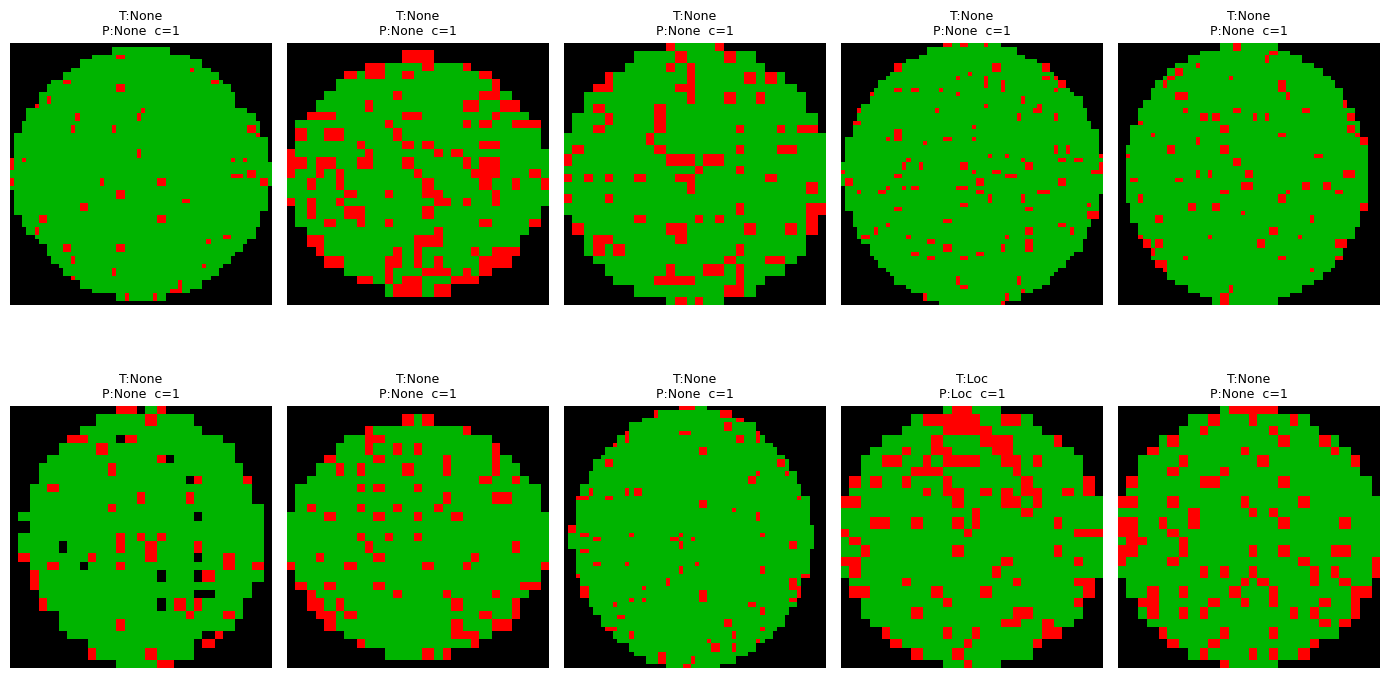


Shown 10 images from fixed sample60:
C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Python\dataset\sample60\None\idx_777356__lot_lot46158__wafer_10.0.png
C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Python\dataset\sample60\None\idx_703441__lot_lot43162__wafer_14.0.png
C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Python\dataset\sample60\None\idx_642439__lot_lot40440__wafer_5.0.png
C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Python\dataset\sample60\None\idx_765075__lot_lot45655__wafer_8.0.png
C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Python\dataset\sample60\None\idx_687485__lot_lot42516__wafer_6.0.png
C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Python\dataset\sample60\None\idx_752999__lot_lot45166__wafer_4.0.png
C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Python\dataset\sample60\None\idx_702623__lot_lot43129__wafer_21.0.png
C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Python\dataset\sample60\None\idx_768759__lot_lot45804__wafer_15.0.png
C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Python\dat

In [8]:
# =========================================================
# Check fixed sample60 folder structure and matching status
# =========================================================


SAMPLE60_DIR = r"C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Python\dataset\sample60"


IMAGE_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}


fixed_paths = []


for root, dirs, files in os.walk(SAMPLE60_DIR):
    for fn in files:
        ext = os.path.splitext(fn)[1].lower()
        if ext in IMAGE_EXTS:
            fixed_paths.append(os.path.join(root, fn))


fixed_paths = sorted(fixed_paths)


df_check = pd.DataFrame({
    "copied_path": fixed_paths
})


df_check["true_folder"] = df_check["copied_path"].apply(
    lambda p: os.path.basename(os.path.dirname(p))
)


df_check["file_name"] = df_check["copied_path"].apply(
    lambda p: os.path.basename(p)
)


print("\n==============================")
print("Sample60 Folder Check")
print("==============================")
print(f"Sample60 folder: {SAMPLE60_DIR}")
print(f"Total image files found: {len(df_check)}")


print("\nPer-class image counts:")
print(df_check["true_folder"].value_counts().sort_index())


print("\nDetected folders:")
print(sorted(df_check["true_folder"].unique().tolist()))


expected_classes = set(CLASS_LIST)
detected_classes = set(df_check["true_folder"].unique().tolist())


missing_classes = expected_classes - detected_classes
extra_classes = detected_classes - expected_classes


print("\nMissing classes:", sorted(missing_classes))
print("Extra folders   :", sorted(extra_classes))


if len(df_check) == 60:
    print("\n[OK] Found exactly 60 images.")
else:
    print(f"\n[WARN] Expected 60 images, but found {len(df_check)} images.")



import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# =========================================================
# 20) Fixed sample60 from folder
# =========================================================
# 固定使用這個資料夾裡的 60 張圖片，不重新隨機抽樣
SAMPLE60_DIR = r"C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Python\dataset\sample60"

# 輸出整理後的 sample60 結果 CSV
OUT_SAMPLE60_CSV = os.path.join(
    DATASET_DIR1,
    "sample60_fixed_from_folder_lr3e5.csv"
)

IMAGE_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

# ---------------------------------------------------------
# 1. 掃描 sample60 資料夾裡的圖片
# ---------------------------------------------------------
fixed_paths = []

for root, dirs, files in os.walk(SAMPLE60_DIR):
    for fn in files:
        ext = os.path.splitext(fn)[1].lower()
        if ext in IMAGE_EXTS:
            fixed_paths.append(os.path.join(root, fn))

fixed_paths = sorted(fixed_paths)

print("\n==============================")
print("Fixed Sample60 Folder Summary")
print("==============================")
print(f"Sample60 folder: {SAMPLE60_DIR}")
print(f"Found images   : {len(fixed_paths)}")

if len(fixed_paths) == 0:
    raise ValueError("No image files found in SAMPLE60_DIR.")

if len(fixed_paths) != 60:
    print(f"[WARN] Expected 60 images, but found {len(fixed_paths)} images.")

# ---------------------------------------------------------
# 2. 建立 df_pick
# ---------------------------------------------------------
df_pick = pd.DataFrame({
    "copied_path": fixed_paths,
})

df_pick["copied_file"] = df_pick["copied_path"].apply(
    lambda p: os.path.basename(p)
)

# 如果你的 sample60 結構是：
# sample60/
# ├── Center/
# ├── Donut/
# ├── None/
# ...
# 則 true_folder 會從上一層資料夾名稱取得。
df_pick["folder_from_path"] = df_pick["copied_path"].apply(
    lambda p: os.path.basename(os.path.dirname(p))
)

# 如果圖片檔名曾經因為重複而變成 xxx__idx003.png，這裡還原成原始檔名
def recover_original_filename(fn):
    name, ext = os.path.splitext(fn)
    name = re.sub(r"__idx\d+$", "", name)
    return name + ext

df_pick["file_key"] = df_pick["copied_file"].apply(recover_original_filename)

# ---------------------------------------------------------
# 3. 取得 df_out
# ---------------------------------------------------------
# df_out 是前面 Two-stage test prediction 產生的結果。
# 如果目前 notebook 裡沒有 df_out，就從 OUT_TEST_CSV 讀回來。
if "df_out" not in globals():
    df_out = pd.read_csv(OUT_TEST_CSV, encoding="utf-8-sig")
    print(f"[INFO] Loaded df_out from: {OUT_TEST_CSV}")

required_cols = [
    "path",
    "true_folder",
    "final_pred",
    "stage1_pred",
    "stage2_pred",
    "stage1_prob_defect",
]

for c in required_cols:
    if c not in df_out.columns:
        raise ValueError(f"df_out missing required column: {c}")

df_out_match = df_out.copy()

df_out_match["file_key"] = df_out_match["path"].astype(str).apply(
    lambda p: os.path.basename(p)
)

# ---------------------------------------------------------
# 4. 判斷 sample60 是否有類別子資料夾
# ---------------------------------------------------------
valid_class_set = set(CLASS_LIST)

has_class_subfolders = df_pick["folder_from_path"].isin(valid_class_set).all()

if has_class_subfolders:
    print("[INFO] Detected class subfolders in sample60.")
    df_pick["true_folder"] = df_pick["folder_from_path"].astype(str)

    merge_cols = [
        "file_key",
        "true_folder",
        "final_pred",
        "stage1_pred",
        "stage2_pred",
        "stage1_prob_defect",
    ]

    df_pick = df_pick.merge(
        df_out_match[merge_cols],
        on=["file_key", "true_folder"],
        how="left",
    )

else:
    print("[WARN] sample60 does not seem to use class subfolders.")
    print("[WARN] Will match images by filename only.")

    merge_cols = [
        "file_key",
        "true_folder",
        "final_pred",
        "stage1_pred",
        "stage2_pred",
        "stage1_prob_defect",
    ]

    df_pick = df_pick.merge(
        df_out_match[merge_cols],
        on="file_key",
        how="left",
    )

# ---------------------------------------------------------
# 5. 檢查是否有圖片沒有對應到 df_out
# ---------------------------------------------------------
unmatched = df_pick[df_pick["final_pred"].isna()].copy()

if len(unmatched) > 0:
    print("\n[WARN] Some sample60 images could not be matched with df_out:")
    print(unmatched[["copied_path", "file_key"]].head(20))
    print(f"[WARN] Total unmatched images: {len(unmatched)}")

# ---------------------------------------------------------
# 6. 計算 correct_1or0
# ---------------------------------------------------------
df_pick["correct_1or0"] = (
    df_pick["final_pred"].astype(str) == df_pick["true_folder"].astype(str)
).astype(int)

# ---------------------------------------------------------
# 7. 輸出 CSV
# ---------------------------------------------------------
os.makedirs(os.path.dirname(OUT_SAMPLE60_CSV), exist_ok=True)

df_pick.to_csv(
    OUT_SAMPLE60_CSV,
    index=False,
    encoding="utf-8-sig"
)

n1 = int((df_pick["correct_1or0"] == 1).sum())
n0 = int((df_pick["correct_1or0"] == 0).sum())

print("\n==============================")
print("Fixed Sample60 Result Summary")
print("==============================")
print(f"Total samples: {len(df_pick)}")
print(f"Correct=1    : {n1}")
print(f"Correct=0    : {n0}")
print(f"Saved CSV    : {OUT_SAMPLE60_CSV}")

print("\nPer-class counts in fixed sample60:")
print(df_pick["true_folder"].value_counts().sort_index())

display(df_pick.head())


# =========================================================
# 21) Show 10 images from fixed sample60
# =========================================================
if "copied_path" not in df_pick.columns:
    raise ValueError("df_pick does not have 'copied_path'.")

SHOW_K = min(10, len(df_pick))

# 固定顯示 10 張，使用固定 SEED，所以每次顯示同樣 10 張
rng_show = np.random.default_rng(SEED + 999)
show_idx = rng_show.choice(len(df_pick), size=SHOW_K, replace=False)

df_show = df_pick.iloc[show_idx].reset_index(drop=True)

plt.figure(figsize=(14, 8))

for i in range(SHOW_K):
    p = str(df_show.loc[i, "copied_path"])
    true_cls = str(df_show.loc[i, "true_folder"])
    pred_cls = str(df_show.loc[i, "final_pred"])
    c10 = int(df_show.loc[i, "correct_1or0"])

    img = Image.open(p).convert("RGB")

    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(
        f"T:{true_cls}\nP:{pred_cls}  c={c10}",
        fontsize=9
    )

plt.tight_layout()
plt.show()

print("\nShown 10 images from fixed sample60:")
for i in range(SHOW_K):
    print(df_show.loc[i, "copied_path"])

print("\nDone.")
# =========================================================
# Check fixed sample60 folder structure and matching status
# =========================================================

SAMPLE60_DIR = r"C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Python\dataset\sample60"

IMAGE_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

fixed_paths = []

for root, dirs, files in os.walk(SAMPLE60_DIR):
    for fn in files:
        ext = os.path.splitext(fn)[1].lower()
        if ext in IMAGE_EXTS:
            fixed_paths.append(os.path.join(root, fn))

fixed_paths = sorted(fixed_paths)

df_check = pd.DataFrame({
    "copied_path": fixed_paths
})

df_check["true_folder"] = df_check["copied_path"].apply(
    lambda p: os.path.basename(os.path.dirname(p))
)

df_check["file_name"] = df_check["copied_path"].apply(
    lambda p: os.path.basename(p)
)

print("\n==============================")
print("Sample60 Folder Check")
print("==============================")
print(f"Sample60 folder: {SAMPLE60_DIR}")
print(f"Total image files found: {len(df_check)}")

print("\nPer-class image counts:")
print(df_check["true_folder"].value_counts().sort_index())

print("\nDetected folders:")
print(sorted(df_check["true_folder"].unique().tolist()))

expected_classes = set(CLASS_LIST)
detected_classes = set(df_check["true_folder"].unique().tolist())

missing_classes = expected_classes - detected_classes
extra_classes = detected_classes - expected_classes

print("\nMissing classes:", sorted(missing_classes))
print("Extra folders   :", sorted(extra_classes))

if len(df_check) == 60:
    print("\n[OK] Found exactly 60 images.")
else:
    print(f"\n[WARN] Expected 60 images, but found {len(df_check)} images.")
